##  Data
We use the IBM Telco Customer Churn dataset from Kaggle.
* **Unit of observation:** One individual telecom customer.
* **Target ($Y$):** `Churn` (Yes/No mapped to 1/0).

In [31]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Download Telco dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Downloaded to:", path)

# Load it
Telco = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print("Shape:", Telco.shape)
Telco.head()

Downloaded to: C:\Users\Leila\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
# ──  First look at the data ──────────────────────────────

# 1. Column types and missing values
print("=== Column Info ===")
print(Telco.dtypes)

# 2. Check churn rate
print("\n=== Churn Rate ===")
print(Telco['Churn'].value_counts())
print(Telco['Churn'].value_counts(normalize=True).round(3) * 100, "%")

# 3. Check for missing values
print("\n=== Missing Values ===")
print(Telco.isnull().sum())

# 4. Fix TotalCharges (stored as string!)
Telco['TotalCharges'] = pd.to_numeric(Telco['TotalCharges'], errors='coerce')
print("\n=== TotalCharges missing after fix ===")
print(Telco['TotalCharges'].isnull().sum())

=== Column Info ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Churn Rate ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity 

In [33]:
# ──  Clean the data ───────────────────────────────────────

# 1. Fix Churn → 0/1
Telco['Churn'] = Telco['Churn'].map({'Yes': 1, 'No': 0})

# 2. Drop the 11 rows with missing TotalCharges
Telco = Telco.dropna(subset=['TotalCharges'])

# 3. Drop customerID - useless column(id)
Telco = Telco.drop(columns=['customerID'])

# 4. Fix "No internet service" -> "No" 
cols_with_no_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
Telco[cols_with_no_internet] = Telco[cols_with_no_internet].replace(
    'No internet service', 'No'
)

# 5. Fix "No phone service" -> "No"
Telco['MultipleLines'] = Telco['MultipleLines'].replace('No phone service', 'No')

# Check
print("=== Shape after cleaning ===")
print(Telco.shape)

print("\n=== Churn distribution ===")
print(Telco['Churn'].value_counts())

print("\n=== Sample ===")
Telco.head(3)

=== Shape after cleaning ===
(7032, 20)

=== Churn distribution ===
Churn
0    5163
1    1869
Name: count, dtype: int64

=== Sample ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


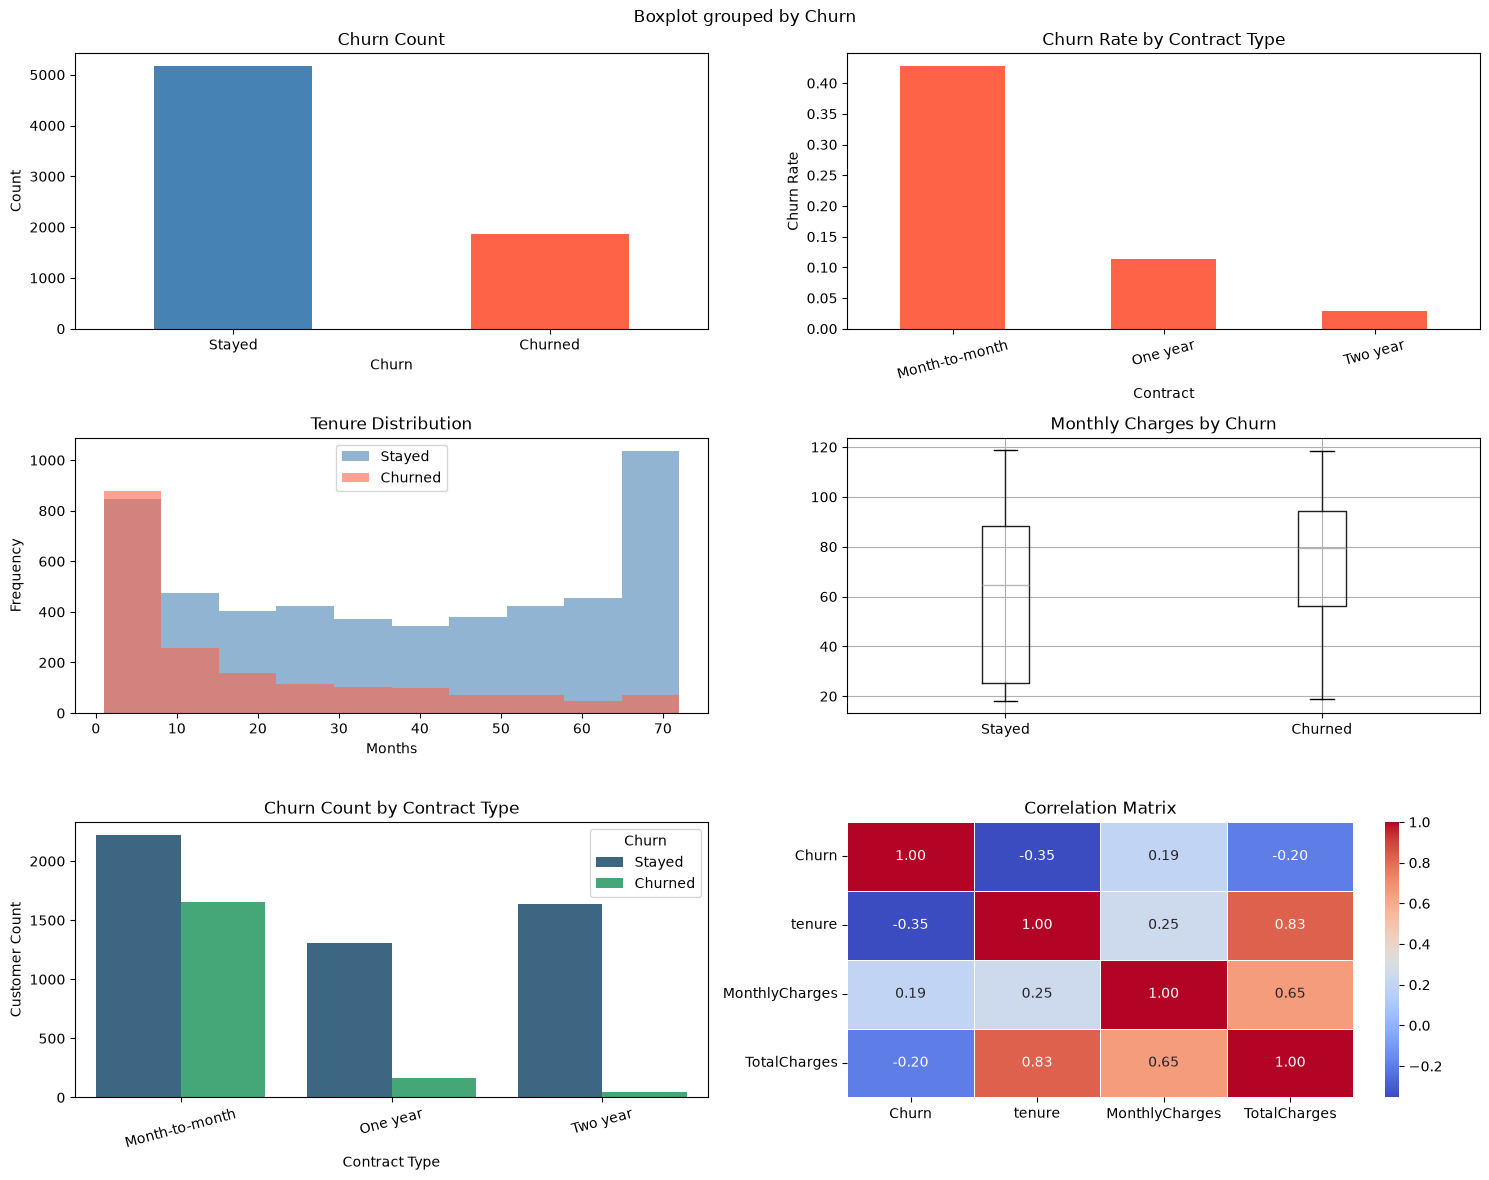

Plot saved!

Key findings:
- TotalCharges & tenure:       0.83
- MonthlyCharges & Churn:      0.19
- tenure & Churn:              -0.35


In [37]:
# ── EDA Visualizations ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Telco Churn — Exploratory Analysis', fontsize=16, y=1.01)

# 1. Churn count
Telco['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Churn Count')
axes[0,0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Churn rate by Contract type
Telco.groupby('Contract')['Churn'].mean().plot(kind='bar', ax=axes[0,1], color='tomato')
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Tenure distribution
Telco[Telco['Churn']==0]['tenure'].plot(kind='hist', ax=axes[1,0], alpha=0.6, label='Stayed', color='steelblue')
Telco[Telco['Churn']==1]['tenure'].plot(kind='hist', ax=axes[1,0], alpha=0.6, label='Churned', color='tomato')
axes[1,0].set_title('Tenure Distribution')
axes[1,0].set_xlabel('Months')
axes[1,0].legend()

# 4. Monthly Charges vs Churn
Telco.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,1])
axes[1,1].set_title('Monthly Charges by Churn')
axes[1,1].set_xlabel('')
axes[1,1].set_xticklabels(['Stayed', 'Churned'])
plt.sca(axes[1,1])
plt.title('Monthly Charges by Churn')

# 5. Contract type vs Churn count
sns.countplot(x='Contract', hue='Churn', data=Telco, palette='viridis', ax=axes[2,0])
axes[2,0].set_title('Churn Count by Contract Type')
axes[2,0].set_xlabel('Contract Type')
axes[2,0].set_ylabel('Customer Count')
axes[2,0].legend(title='Churn', labels=['Stayed', 'Churned'])
axes[2,0].tick_params(axis='x', rotation=15)

# 6. Correlation heatmap
numerical_corr = Telco[['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, ax=axes[2,1])
axes[2,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('../data/eda_plots.png', bbox_inches='tight')
plt.show()

print("Plot saved!")
print(f"\nKey findings:")
print(f"- TotalCharges & tenure:       {numerical_corr.loc['TotalCharges','tenure']:.2f}")
print(f"- MonthlyCharges & Churn:      {numerical_corr.loc['MonthlyCharges','Churn']:.2f}")
print(f"- tenure & Churn:              {numerical_corr.loc['tenure','Churn']:.2f}")